# Getting Started with **Qiskit**
### A Hands-On Introduction for the Quantum Computing Education Series by Trinexis

---

**Welcome!** This notebook is a *self-contained, run-from-top-to-bottom* introduction to
[Qiskit](https://www.ibm.com/quantum/qiskit) — IBM's open-source Python framework for
quantum computing, and (alongside PennyLane) one of the two frameworks anchoring this
session's tour of the **quantum software ecosystem**.

So far in this course you have built everything *by hand* with **NumPy** — state vectors,
gates, the Born rule, the Bloch sphere, density matrices, noise channels, and even your
own from-scratch statevector simulator with a circuit-diagram drawer. You have also met
**PennyLane**, whose signature strength is *differentiable* quantum programming. Qiskit
comes from a different lineage: it grew up as the interface to **real IBM Quantum
hardware**, and its design reflects that — an explicit circuit object, a rich transpiler
that maps circuits onto real device constraints, and two workhorse *primitives*
(`Sampler` and `Estimator`) that mediate everything you actually run.

### What you will learn
1. The anatomy of a Qiskit **circuit** and how it is simulated with `Statevector`.
2. **Measurement**, sampling, and the `Sampler` primitive.
3. **Deutsch's algorithm**, full circle — the same algorithm you built by hand in
   Notebook 1, now in a handful of Qiskit lines.
4. **Entanglement** the Qiskit way — Bell and GHZ states.
5. **Parameterised circuits** and the `Estimator` primitive for expectation values.
6. Why Qiskit has **no automatic differentiation** — and how to compute exact gradients
   yourself with the **parameter-shift rule**.
7. A small **variational loop** (a miniature VQE) trained by hand.
8. **Transpilation** — how an abstract circuit becomes a hardware-runnable one.
9. A guided tour of the **wider ecosystem**: Aer, algorithm libraries, and real hardware
   access via IBM Quantum.
10. **Graded exercises** (★ to ★★★) with hidden solutions.

### How to use this notebook
- Runs in **Google Colab** with no setup beyond the install cell below.
- Run cells **in order** with `Shift + Enter`.
- Try the exercises *before* peeking at the solutions.

> **Tip:** In Colab, go to *Runtime → Run all* to execute everything once, then come back
> and experiment cell by cell.


## 0  Setup — installing and importing

The cell below installs **Qiskit** if it is not already present. `pylatexenc` is a small
extra dependency needed only for the nicer `draw('mpl')` circuit diagrams. On a fresh
Colab runtime neither is preinstalled, so this may take a minute the first time.

The install only runs for packages that are missing, so this cell is safe to re-run.


In [1]:
# --- Install dependencies only if they are missing ---------------------------
import importlib, subprocess, sys

for package, pip_name in [("qiskit", "qiskit"), ("pylatexenc", "pylatexenc")]:
    if importlib.util.find_spec(package) is None:
        print(f"Installing {pip_name} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"{package} already available.")


Installing qiskit ...
Installing pylatexenc ...


In [2]:
# --- Core imports ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit.visualization import plot_histogram

# Reproducibility: fix the random seed used anywhere sampling is involved.
np.random.seed(42)

print("Qiskit version:", qiskit.__version__)


Qiskit version: 2.5.0


> **Note on installs:** unlike some Qiskit tutorials you may have seen, we will **not**
> need `qiskit-aer`. Qiskit's core `quantum_info.Statevector` class already gives us an
> exact classical simulator for the small circuits (≤ 4 qubits) in this notebook, and the
> core `primitives` module ships reference `Sampler`/`Estimator` implementations that need
> no extra backend. This keeps installs light and robust on a fresh runtime. Aer earns its
> place later — see §9 — once circuits get larger or you want configurable noise models.


## 1  Anatomy of a Qiskit circuit

A `QuantumCircuit` is an **ordered list of gates** acting on a register of qubits — exactly
the "ordered unitary product" you formalised in the circuits notebook. Let's build the
simplest nontrivial circuit: a Hadamard on one qubit.


In [3]:
qc = QuantumCircuit(1)
qc.h(0)

print("Text diagram:")
print(qc.draw())


Text diagram:
   ┌───┐
q: ┤ H ├
   └───┘


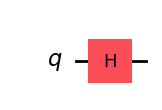

In [4]:
# The matplotlib diagram is what we usually show in a talk or a paper.
qc.draw('mpl')


Under the hood, `qc.h(0)` appends the same $2\times2$ Hadamard matrix
$$
H=\frac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}
$$
you have used since Notebook 1 — Qiskit just tracks the bookkeeping (which qubit, which
order, how to draw it) for you.


## 2  Simulating a circuit: `Statevector`

`Statevector.from_instruction` applies the circuit to $|0\ldots0\rangle$ and returns the
resulting amplitude vector — the exact analogue of the `QuantumCircuit` class you built
by hand in the circuits & entangling gates notebook, now as a tested library call.


In [5]:
sv = Statevector.from_instruction(qc)
print("Amplitudes:", sv.data)
print("Probabilities:", sv.probabilities_dict())


Amplitudes: [0.70710678+0.j 0.70710678+0.j]
Probabilities: {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


Notice `probabilities_dict()` returns $\{0: 0.5,\ 1: 0.5\}$ — this **is** your
unifying thesis in library form: *probabilities are squared magnitudes of amplitudes*,
$p_i = |\langle i|\psi\rangle|^2$. Nothing new has happened physically; only the
bookkeeping has moved from your NumPy arrays into a maintained library.


## 3  Measurement and sampling: the `Sampler` primitive

`Statevector` gives *exact* probabilities — useful for understanding, but real hardware
(and real experiments) only ever return **samples**. The `Sampler` primitive turns a
circuit-with-measurements into shot-based counts, the Qiskit equivalent of the Born-rule
Monte Carlo bar charts from your Stern–Gerlach notebook.


Counts over 1000 shots: {'1': 497, '0': 503}


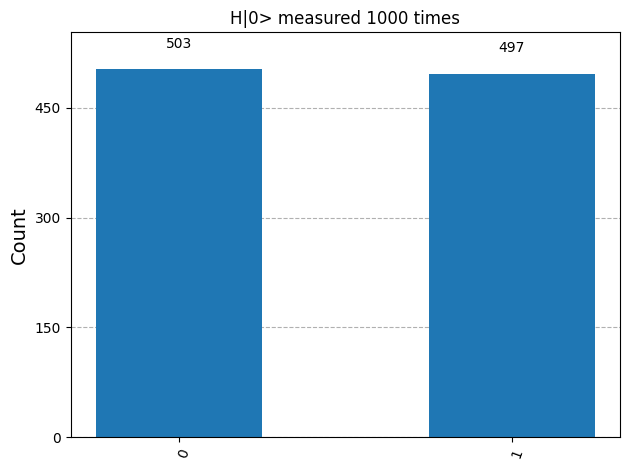

In [21]:
qc_meas = QuantumCircuit(1, 1)
qc_meas.h(0)
#qc_meas.draw('mpl')
qc_meas.measure(0, 0)

sampler = StatevectorSampler(seed=42)
job = sampler.run([qc_meas], shots=1000)
counts = job.result()[0].data.c.get_counts()

print("Counts over 1000 shots:", counts)

plot_histogram(counts, title="H|0> measured 1000 times")


Roughly half-and-half, as expected — with the same shot-noise fluctuation you saw
when you built this Monte Carlo logic by hand.


## 4  Full circle: Deutsch's algorithm in Qiskit

Back in **Notebook 1** you built Deutsch's algorithm from raw matrices to distinguish a
*constant* function ($f(x)=0$ for all $x$) from a *balanced* one ($f(x)=x$) with a
**single** oracle query — impossible classically. Let's see the same algorithm in
production Qiskit.


Oracle = constant  -> measured qubit 0 counts = {'0': 1000}  =>  algorithm says 'constant'
Oracle = balanced  -> measured qubit 0 counts = {'1': 1000}  =>  algorithm says 'balanced'


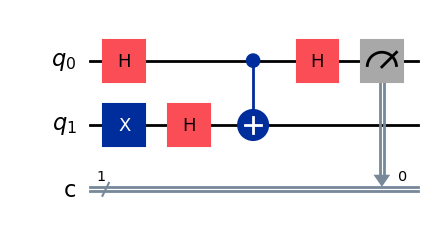

In [7]:
def deutsch_circuit(balanced):
    """Two-qubit Deutsch circuit. Qubit 0 = query, qubit 1 = ancilla (prepared in |->)."""
    qc = QuantumCircuit(2, 1)
    qc.x(1)             # ancilla -> |1>
    qc.h(0)
    qc.h(1)             # ancilla -> |->
    if balanced:
        qc.cx(0, 1)     # oracle for f(x) = x
    # constant oracle f(x) = 0: do nothing (identity)
    qc.h(0)
    qc.measure(0, 0)
    return qc

sampler = StatevectorSampler(seed=42)
for balanced, label in [(False, "constant"), (True, "balanced")]:
    qc = deutsch_circuit(balanced)
    counts = sampler.run([qc], shots=1000).result()[0].data.c.get_counts()
    verdict = "balanced" if "1" in counts and counts.get("1", 0) > counts.get("0", 0) else "constant"
    print(f"Oracle = {label:9s} -> measured qubit 0 counts = {counts}  =>  algorithm says '{verdict}'")

deutsch_circuit(True).draw('mpl')


One circuit, one shot in principle, a deterministic answer either way — the same
interference-based logic you derived by hand, now expressed in eight lines of Qiskit.


## 5  Entanglement with the Qiskit: Bell and GHZ states

Straight from your entanglement module (Notebook 4) and circuits module: the canonical
two- and three-qubit maximally entangled states.


Bell probabilities: {np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}
GHZ probabilities:  {np.str_('000'): np.float64(0.4999999999999999), np.str_('111'): np.float64(0.4999999999999999)}


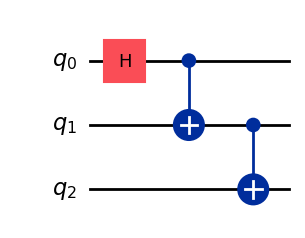

In [22]:
# Bell state (Phi+)
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
print("Bell probabilities:", Statevector.from_instruction(bell).probabilities_dict())

# GHZ state
ghz = QuantumCircuit(3)
ghz.h(0)
ghz.cx(0, 1)
ghz.cx(1, 2)
print("GHZ probabilities: ", Statevector.from_instruction(ghz).probabilities_dict())

bell.draw('mpl')
#ghz.draw('mpl')


Only $|00\rangle,|11\rangle$ (Bell) and $|000\rangle,|111\rangle$ (GHZ) ever appear —
$|01\rangle$, $|10\rangle$, and every mixed-parity GHZ outcome have probability exactly
zero. Measure one qubit and you instantly know the rest, yet no qubit has a definite
value on its own: *indistinguishable alternatives interfere*, now at the multi-qubit
level, exactly as in your circuits notebook.


## 6  Parameterised circuits

A `Parameter` is a placeholder angle one can bind to a numerical value later — this is
what makes **variational algorithms** possible: the circuit *shape* stays fixed while its
parameters get tuned by a classical optimiser.


In [9]:
theta = Parameter('theta')
qc_param = QuantumCircuit(1)
qc_param.rx(theta, 0)

print(qc_param.draw())

# Binding a value produces an ordinary, runnable circuit
bound = qc_param.assign_parameters({theta: np.pi / 3})
print("\nBound circuit statevector (theta = pi/3):", Statevector.from_instruction(bound).data)


   ┌───────────┐
q: ┤ Rx(theta) ├
   └───────────┘

Bound circuit statevector (theta = pi/3): [0.8660254+0.j  0.       -0.5j]


## 7  Expectation values: the `Estimator` primitive

Where `Sampler` gives you bitstring counts, `Estimator` gives you the **expectation
value** of an observable directly — the workhorse for chemistry, optimisation, and
variational algorithms. Observables are built with `SparsePauliOp`.


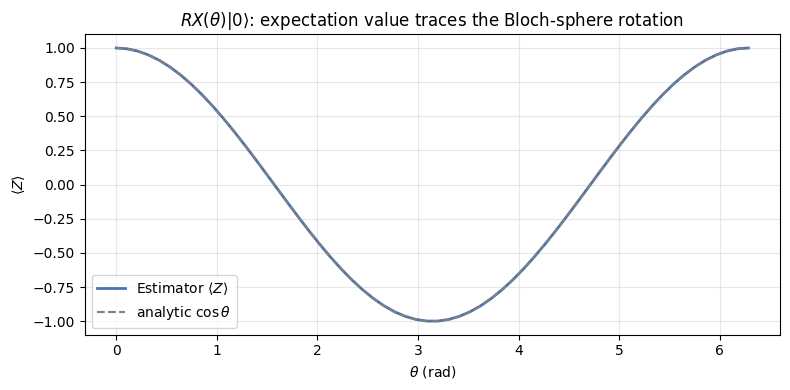

In [10]:
obs_z = SparsePauliOp.from_list([("Z", 1.0)])
est = StatevectorEstimator()

def expZ(theta_val):
    bound = qc_param.assign_parameters({theta: theta_val})
    return float(est.run([(bound, obs_z)]).result()[0].data.evs)

thetas = np.linspace(0, 2*np.pi, 60)
z_vals = [expZ(t) for t in thetas]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thetas, z_vals, lw=2, color="#4C72B0", label=r"Estimator $\langle Z\rangle$")
ax.plot(thetas, np.cos(thetas), '--', color="gray", label=r"analytic $\cos\theta$")
ax.set_xlabel(r"$\theta$ (rad)"); ax.set_ylabel(r"$\langle Z\rangle$")
ax.set_title(r"$RX(\theta)|0\rangle$: expectation value traces the Bloch-sphere rotation")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


Exactly the $\cos\theta$ curve you would expect from an $x$-axis Bloch-sphere
rotation of a state that starts pointing along $+z$ — the Estimator is just reading off
the same geometry you have been tracking by hand since Notebook 2/3.

### Try it yourself


In [11]:
# Interactive: drag the slider to see <Z> update live (works fully in Colab).
# In a headless/static export the widget still renders; a few reference values are
# printed alongside it so the notebook remains useful even without a live kernel.
try:
    import ipywidgets as widgets
    from ipywidgets import interact

    @interact(theta_deg=widgets.FloatSlider(min=0, max=360, step=5, value=0,
                                             description='theta (deg)'))
    def explore_theta(theta_deg):
        th = np.deg2rad(theta_deg)
        z_val = expZ(th)
        print(f"theta = {theta_deg:6.1f} deg   <Z> = {z_val:+.3f}   cos(theta) = {np.cos(th):+.3f}")
except Exception as e:
    print("Interactive widget unavailable here — static reference values instead:")
    for deg in [0, 90, 180, 270]:
        th = np.deg2rad(deg)
        print(f"theta = {deg:3d} deg   <Z> = {expZ(th):+.3f}   cos(theta) = {np.cos(th):+.3f}")


interactive(children=(FloatSlider(value=0.0, description='theta (deg)', max=360.0, step=5.0), Output()), _dom_…

## 8  Qiskit has no built-in autodiff — the parameter-shift rule, by hand

This is the single biggest **architectural** difference from PennyLane. PennyLane wraps
every `QNode` so `qml.grad` "just works." Qiskit's `Estimator` gives you expectation
*values*, not gradients — you are expected to bring your own optimiser (or reach for the
separate `qiskit-algorithms` package; see §11).

That is not a limitation to work around — it is the **same exact rule** every
differentiable-programming framework uses under the hood. For a single-Pauli-generator
gate such as $RX(\theta)=e^{-i\theta X/2}$, the expectation value of any observable is
*exactly* sinusoidal in $\theta$:
$$
f(\theta) = A\cos(\theta+\phi) + C \quad\Longrightarrow\quad
f'(\theta) = \tfrac12\big[f(\theta+\tfrac{\pi}{2}) - f(\theta-\tfrac{\pi}{2})\big].
$$
This is **exact**, not a finite-difference approximation — no shrinking step size, no
truncation error. (The full derivation is in the companion lecture document, §Appendix A.)


In [12]:
shift = np.pi / 2

def grad_paramshift(theta_val):
    return (expZ(theta_val + shift) - expZ(theta_val - shift)) / 2

theta0 = np.pi / 4
g_shift = grad_paramshift(theta0)
g_exact = -np.sin(theta0)
print(f"parameter-shift gradient at theta=pi/4 : {g_shift:.6f}")
print(f"analytic  -sin(theta)                  : {g_exact:.6f}")
print(f"difference                             : {abs(g_shift - g_exact):.2e}   (should be ~machine precision)")


parameter-shift gradient at theta=pi/4 : -0.707107
analytic  -sin(theta)                  : -0.707107
difference                             : 0.00e+00   (should be ~machine precision)


## 9  Putting it together: a miniature VQE

Now the full pattern behind every **Variational Quantum Algorithm**: a parameterised
ansatz + the `Estimator` + parameter-shift gradients + a classical optimiser, all in one
loop. We will find the ground-state energy of the toy two-qubit Hamiltonian
$$
H = Z\otimes Z
$$
whose exact eigenvalues you can read off directly: $\pm1$, each doubly degenerate — so
the true ground energy is $-1$.


Optimised energy : -1.000000
Exact ground state: -1.000000


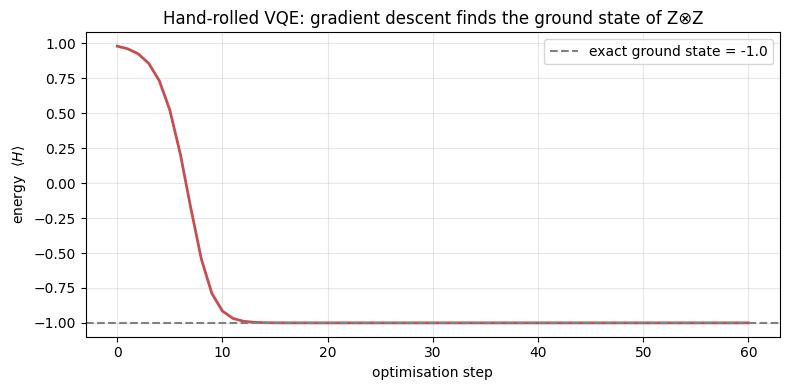

In [13]:
t1, t2 = Parameter('t1'), Parameter('t2')
ansatz = QuantumCircuit(2)
ansatz.ry(t1, 0)
ansatz.ry(t2, 1)
ansatz.cx(0, 1)

H_zz = SparsePauliOp.from_list([("ZZ", 1.0)])
est = StatevectorEstimator()

def energy(params, H=H_zz):
    bound = ansatz.assign_parameters({t1: params[0], t2: params[1]})
    return float(est.run([(bound, H)]).result()[0].data.evs)

def grad_energy(params, H=H_zz):
    g = np.zeros(2)
    for i in range(2):
        p_plus, p_minus = params.copy(), params.copy()
        p_plus[i] += shift
        p_minus[i] -= shift
        g[i] = (energy(p_plus, H) - energy(p_minus, H)) / 2
    return g

params = np.array([0.30, 0.20])
lr = 0.4
history = [energy(params)]
for step in range(60):
    params = params - lr * grad_energy(params)
    history.append(energy(params))

exact_ground = np.linalg.eigvalsh(H_zz.to_matrix()).min()
print(f"Optimised energy : {history[-1]:.6f}")
print(f"Exact ground state: {exact_ground:.6f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history, lw=2, color="#C44E52")
ax.axhline(exact_ground, ls="--", color="gray", label=f"exact ground state = {exact_ground:.1f}")
ax.set_xlabel("optimisation step"); ax.set_ylabel(r"energy  $\langle H\rangle$")
ax.set_title("Hand-rolled VQE: gradient descent finds the ground state of Z⊗Z")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


The optimiser — using nothing but the parameter-shift formula from §8, applied
twice (once per parameter) — lands exactly on the true ground-state energy. This is the
entire idea behind `qiskit-algorithms.VQE`: what you just wrote by hand *is* a minimal
VQE.


## 10  Transpilation: from abstract circuit to hardware-runnable circuit

Real quantum processors only implement a small, fixed set of **native gates**. The
**transpiler** rewrites your circuit into an equivalent one built exclusively from that
basis — the same way a compiler lowers high-level code to a specific instruction set.


Original gate counts : {'h': 1, 'cx': 1}
Transpiled gate counts: {'rz': 2, 'sx': 1, 'cx': 1}


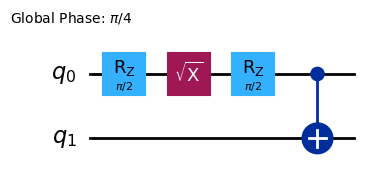

In [14]:
qc_to_transpile = QuantumCircuit(2)
qc_to_transpile.h(0)
qc_to_transpile.cx(0, 1)

print("Original gate counts :", dict(qc_to_transpile.count_ops()))

transpiled = transpile(qc_to_transpile, basis_gates=['rz', 'sx', 'x', 'cx'], optimization_level=1)
print("Transpiled gate counts:", dict(transpiled.count_ops()))

transpiled.draw('mpl')


The Hadamard has vanished — decomposed into the rotation gates a real device
actually implements ($R_Z$ and $\sqrt{X}$ are IBM hardware-native single-qubit gates).
Nothing about the *physics* changed; only the vocabulary used to express it, exactly as
the Walsh–Hadamard / gate-decomposition ideas from earlier notebooks would predict.


## 11  The wider ecosystem (a guided tour, not a deep dive)

What you have used so far — `qiskit` core, `Statevector`, `Sampler`, `Estimator` — is
deliberately the *lightest* path through Qiskit. Three more pieces are worth knowing
exist, even though we will not install or run them here.

**`qiskit-aer`** — a high-performance simulator supporting **configurable noise models**
(depolarising, thermal relaxation, readout error — the same channels from your noise
notebook, but parameterised to match real hardware calibration data) and circuits far
too large for exact `Statevector` simulation. You would reach for Aer once you want to
ask "how would *this specific* noisy device perform?" rather than "what is the ideal
answer?"

**`qiskit-algorithms`** — pre-built `VQE`, `QAOA`, and classical optimiser classes
(`SPSA`, `COBYLA`, ...). We built §9's loop by hand for the same reason your earlier
notebooks built a statevector simulator by hand before ever importing Qiskit: once you
have done it yourself, the library version stops being a black box.

**`qiskit-ibm-runtime`** — the client for **real IBM Quantum hardware**. Conceptually,
the same `Sampler`/`Estimator` primitives you used above, but backed by an actual
superconducting-qubit processor in the cloud. It needs a free IBM Quantum account and an
API token — nothing below is executed here, it is illustrative only:

```python
# Illustrative only — requires your own IBM Quantum account & token, not run in this notebook.
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
service = QiskitRuntimeService(channel="ibm_quantum_platform", token="<your token>")
backend = service.least_busy(operational=True, simulator=False)
# ... transpile qc for backend.target, then:
# result = Sampler(mode=backend).run([isa_circuit]).result()
```

Queue times, calibration drift, and real decoherence all become visible the moment you
swap a simulator for `backend` — a good practical demonstration, later in the course, of
everything the noise-channels notebook predicted in the abstract.

**Further reading:** [Qiskit documentation](https://docs.quantum.ibm.com/) ·
[Qiskit Textbook](https://qiskit.org/learn) · [IBM Quantum Platform](https://quantum.ibm.com/)


## 12  Graded exercises

Try each before revealing the solution. All three scaffolds run without errors — but
they will not yet give the *correct* answer until you complete the missing piece, so
you'll know immediately when you're done rather than by coincidence.


### Exercise 1 (★) — GHZ-4

Extend the Bell/GHZ pattern from §5 to build the **four-qubit** GHZ state
$\tfrac{1}{\sqrt2}\big(|0000\rangle+|1111\rangle\big)$.


In [15]:
qc_ex1 = QuantumCircuit(4)
qc_ex1.h(0)
# >>> YOUR CODE HERE <<<
# Chain CX gates so that qubits 1, 2, and 3 all become entangled with qubit 0's
# superposition (hint: cx(0,1), cx(1,2), cx(2,3)).


probs_ex1 = Statevector.from_instruction(qc_ex1).probabilities_dict()
print("Probabilities:", probs_ex1)
print("Is this the 2-outcome GHZ-4 pattern ({'0000': 0.5, '1111': 0.5})? ",
      set(probs_ex1.keys()) == {'0000', '1111'})


Probabilities: {np.str_('0000'): np.float64(0.4999999999999999), np.str_('0001'): np.float64(0.4999999999999999)}
Is this the 2-outcome GHZ-4 pattern ({'0000': 0.5, '1111': 0.5})?  False


<details>
<summary><b>Solution (click to reveal)</b></summary>

```python
qc_ex1 = QuantumCircuit(4)
qc_ex1.h(0)
qc_ex1.cx(0, 1)
qc_ex1.cx(1, 2)
qc_ex1.cx(2, 3)

probs_ex1 = Statevector.from_instruction(qc_ex1).probabilities_dict()
print("Probabilities:", probs_ex1)   # {'0000': 0.5, '1111': 0.5}
```
</details>


### Exercise 2 (★★) — a different Hamiltonian

Reuse the §9 machinery, but for $H = X\otimes X$ instead of $Z\otimes Z$. Its exact
ground-state energy is also $-1$ (same eigenvalue spectrum, different eigenbasis) — but
the ansatz that reaches it is different, since $X\otimes X$ is diagonal in a different
basis.


In [16]:
H_xx = SparsePauliOp.from_list([("XX", 1.0)])

def energy_ex2(params, H=H_xx):
    # >>> YOUR CODE HERE <<<
    # Replace this placeholder with a real Estimator evaluation, exactly like `energy()`
    # in §9, but using the ansatz and Hamiltonian passed in here.
    return 0.0   # placeholder -- always reports zero energy, which is NOT the answer

params0 = np.array([0.30, 0.20])
print("Energy at initial params (should NOT be 0.0 once implemented):", energy_ex2(params0))


Energy at initial params (should NOT be 0.0 once implemented): 0.0


<details>
<summary><b>Solution (click to reveal)</b></summary>

```python
H_xx = SparsePauliOp.from_list([("XX", 1.0)])

def energy_ex2(params, H=H_xx):
    bound = ansatz.assign_parameters({t1: params[0], t2: params[1]})
    return float(est.run([(bound, H)]).result()[0].data.evs)

def grad_energy_ex2(params, H=H_xx):
    g = np.zeros(2)
    for i in range(2):
        p_plus, p_minus = params.copy(), params.copy()
        p_plus[i] += shift
        p_minus[i] -= shift
        g[i] = (energy_ex2(p_plus, H) - energy_ex2(p_minus, H)) / 2
    return g

params = np.array([0.30, 0.20])
for step in range(60):
    params = params - 0.4 * grad_energy_ex2(params)

print("Optimised energy:", energy_ex2(params))       # -> -1.0
print("Exact ground state:", np.linalg.eigvalsh(H_xx.to_matrix()).min())   # -> -1.0
```
</details>


### Exercise 3 (★★★) — a harder Hamiltonian needs a deeper ansatz

$$
H = X\otimes X + 0.7\,(Z\otimes I) + 0.4\,(I\otimes X) + 0.3\,(Z\otimes Z)
$$

The shallow one-layer ansatz from §9 is **not expressive enough** to reach this
Hamiltonian's true ground state — its 2-parameter family of reachable states simply does
not contain the true minimiser. Add a second $RY$–$CX$ layer (four parameters total) and
verify the deeper ansatz gets much closer to the exact answer than the shallow one does.


In [17]:
H_hard = SparsePauliOp.from_list([("XX", 1.0), ("ZI", 0.7), ("IX", 0.4), ("ZZ", 0.3)])
exact_hard = np.linalg.eigvalsh(H_hard.to_matrix()).min()
print("Exact ground energy of H_hard:", exact_hard)

# Shallow ansatz (from Sec 9) for reference -- expect this to fall short.
def energy_shallow(params):
    bound = ansatz.assign_parameters({t1: params[0], t2: params[1]})
    return float(est.run([(bound, H_hard)]).result()[0].data.evs)

def grad_shallow(params):
    g = np.zeros(2)
    for i in range(2):
        p_plus, p_minus = params.copy(), params.copy()
        p_plus[i] += shift; p_minus[i] -= shift
        g[i] = (energy_shallow(p_plus) - energy_shallow(p_minus)) / 2
    return g

params_shallow = np.array([0.30, 0.20])
for _ in range(150):
    params_shallow = params_shallow - 0.4 * grad_shallow(params_shallow)
print("Shallow (1-layer) ansatz best energy:", energy_shallow(params_shallow))

# >>> YOUR CODE HERE <<<
# Build a deeper 4-parameter ansatz: RY(a0) on q0, RY(a1) on q1, CX(0,1),
# RY(a2) on q0, RY(a3) on q1, CX(0,1) -- then repeat the parameter-shift
# gradient-descent loop over all four parameters and compare to `exact_hard`.


Exact ground energy of H_hard: -1.72065556157337
Shallow (1-layer) ansatz best energy: -1.6042423166894948


<details>
<summary><b>Solution (click to reveal)</b></summary>

```python
a0, a1, a2, a3 = Parameter('a0'), Parameter('a1'), Parameter('a2'), Parameter('a3')
deep_ansatz = QuantumCircuit(2)
deep_ansatz.ry(a0, 0); deep_ansatz.ry(a1, 1); deep_ansatz.cx(0, 1)
deep_ansatz.ry(a2, 0); deep_ansatz.ry(a3, 1); deep_ansatz.cx(0, 1)

def energy_deep(params):
    bound = deep_ansatz.assign_parameters({a0: params[0], a1: params[1],
                                            a2: params[2], a3: params[3]})
    return float(est.run([(bound, H_hard)]).result()[0].data.evs)

def grad_deep(params):
    g = np.zeros(4)
    for i in range(4):
        p_plus, p_minus = params.copy(), params.copy()
        p_plus[i] += shift; p_minus[i] -= shift
        g[i] = (energy_deep(p_plus) - energy_deep(p_minus)) / 2
    return g

params_deep = np.array([0.30, 0.20, 0.10, 0.10])
for _ in range(150):
    params_deep = params_deep - 0.4 * grad_deep(params_deep)

print("Deep (2-layer) ansatz best energy:", energy_deep(params_deep))
print("Exact ground energy             :", exact_hard)
# The deep ansatz should land much closer to exact_hard than the shallow one did.
```
</details>


## 13  Recap & where to go next

**What we covered**
- A Qiskit circuit is an ordered gate list; `Statevector` simulates it exactly, no Aer
  required for small circuits.
- `Sampler` returns shot-based counts; `Estimator` returns expectation values directly.
- Deutsch's algorithm, Bell states, and GHZ states — all concepts you built by hand,
  now in production code.
- Qiskit has **no built-in autodiff** — you compute gradients yourself with the
  parameter-shift rule, which is *exact*, not approximate.
- A hand-rolled miniature VQE finds the exact ground state of a toy Hamiltonian.
- **Transpilation** rewrites a circuit into a hardware's native gate set.
- The wider ecosystem — Aer, `qiskit-algorithms`, and real hardware via
  `qiskit-ibm-runtime` — extends everything here to noisy, large-scale, or physical
  devices.

**Where this connects**
- The parameter-shift rule you derived here is exactly the tool the **Bell/CHSH
  notebook** (coming up next in the course) will use to estimate correlation
  expectation values $\langle ZZ\rangle,\langle ZX\rangle,\langle XZ\rangle,\langle
  XX\rangle$ for the CHSH inequality.
- See the companion **`Qiskit_PennyLane_Synthesis_and_Comparison.ipynb`** notebook for a
  direct, side-by-side rerun of the §9 training task in PennyLane — same physics,
  different mechanics, identical answer.

**Official resources**
- Documentation: <https://docs.quantum.ibm.com/>
- Qiskit Textbook: <https://qiskit.org/learn>
- IBM Quantum Platform: <https://quantum.ibm.com/>

---
*Prepared for the Quantum Computing Education Series by Trinexis. Runs on Google Colab — Runtime → Run all.*
